# lec02-dev

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("svg")

# DSC 80 preferred styles
pio.templates["dsc80"] = go.layout.Template(
    layout=dict(
        margin=dict(l=30, r=30, t=30, b=30),
        autosize=True,
        xaxis=dict(showgrid=True),
        yaxis=dict(showgrid=True),
        title=dict(x=0.5, xanchor="center"),
    )
)
pio.templates.default = "simple_white+dsc80"

import warnings
warnings.simplefilter('ignore')

import datetime

In [2]:
h = np.linspace(0, 10, 1000)
f = np.abs(5 - h)

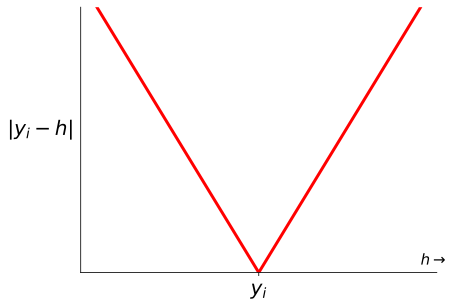

In [3]:
ax = plt.subplot(111)
ax.plot(h, f, color='red', linewidth=3)
plt.ylim(0, 5)
plt.xticks([5], [r'$y_i$'], fontsize=20)
plt.yticks([])
# plt.xlabel('$h$', fontsize=20, labelpad=10)
plt.ylabel(r'$|y_i - h|$', rotation=0, fontsize=20, labelpad=40)
# plt.annotate(r'where $h = y_i$', (3.5, 2), fontsize=15)
plt.annotate(r'$h \rightarrow$', (10, .15), fontsize=15)
ax.spines[['right', 'top']].set_visible(False)
plt.savefig('../imgs/absolute-loss.png', bbox_inches='tight', transparent=True, dpi=200)

In [4]:
vals = np.array([72, 90, 61, 85, 92])

([], [])

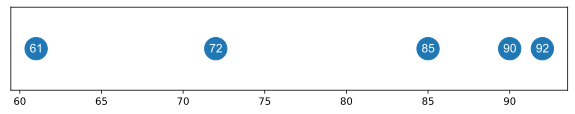

In [5]:
plt.figure(figsize=(10, 1.5), dpi=200)
plt.scatter(vals, [0] * 5, s=500)
plt.xticks(sorted((set(range(60, 95, 5)))))
plt.ylim(-0.2, 0.2)
for val in vals:
    plt.annotate(val, (val-0.4, -0.018), fontsize=12, color='white', font='Arial')
plt.yticks([])

In [ ]:
vals

In [ ]:
plt.figure(figsize=(10, 3),dpi=300)
plt.plot([-3, 5], [80, 80], color='orange', linewidth=4)

for i, val in enumerate(vals):
    plt.plot([i, i], [val, 80], '--', color='black', linewidth=2)
    
plt.scatter(range(5), vals, s=300, zorder=3)


plt.xlim(-0.5, 4.5)
plt.xticks([])
plt.ylim(55, 100)

for i, val in enumerate(vals):
    plt.annotate(val, (i-0.05, val-0.6), fontsize=10, color='white', font='Arial')


plt.annotate('Example prediction, $h=85$', (-2.5, 81))

;

In [ ]:
def R(h):
    return 0.2 * sum([np.abs(val - h) ** 50 for val in vals])

In [ ]:
vals2 = np.array([72, 90, 61, 85, 92, 75])

In [ ]:
def Reven(h):
    return (1 / 6) * sum([np.abs(val - h) for val in vals2])

In [ ]:
R(100)

In [ ]:
h = np.linspace(np.min(vals) - 5, np.max(vals) + 12, 100)
Rh = R(h)

In [ ]:
pio.renderers.default = 'plotly_mimetype+notebook'

In [ ]:
px.line(x=h, y=Rh).update_traces(line_color='purple', line_width=4) \
.update_xaxes(title=r'$h$').update_yaxes(title=r'$R_\text{abs}(h)$') \
.update_layout(width=600, height=350,
               title=r'$R_\text{abs}(h) = \frac{1}{5} \left(|72-h| +|90 - h| +|61 - h| +|85 - h| +|92 - h| \right)$')

In [ ]:
px.line(x=h, y=Reven(h)).update_traces(line_color='purple', line_width=4) \
.update_xaxes(title=r'$h$').update_yaxes(title=r'$R_\text{abs}(h)$') \
.update_layout(width=600, height=350,
               title=r'$R_\text{abs}(h) = \frac{1}{6} \left(|72-h| +|90 - h| +|61 - h| +|85 - h| +|92 - h| + |75-h| \right)$')